<a href="https://colab.research.google.com/github/AngeloSorte/nasa-ndvi-vegetation-stress-classification/blob/angelosorte.github.io/Vegetation_Stress_Analysis_(NASA_MODIS_NDVI_%2B_ML_Classification).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

✅ Earth Engine ready
Europe | NDVI=5025.7980 | slope=-5.347354
Africa | NDVI=3177.8501 | slope=14.406196
Asia | NDVI=2988.8897 | slope=11.279137

DATASET
   region    mean_ndvi      slope  label
0  Europe  5025.798037  -5.347354      1
1  Africa  3177.850150  14.406196      0
2    Asia  2988.889733  11.279137      0

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       0.0
           1       0.00      0.00      0.00       1.0

    accuracy                           0.00       1.0
   macro avg       0.00      0.00      0.00       1.0
weighted avg       0.00      0.00      0.00       1.0


CONFUSION MATRIX
[[0 0]
 [1 0]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

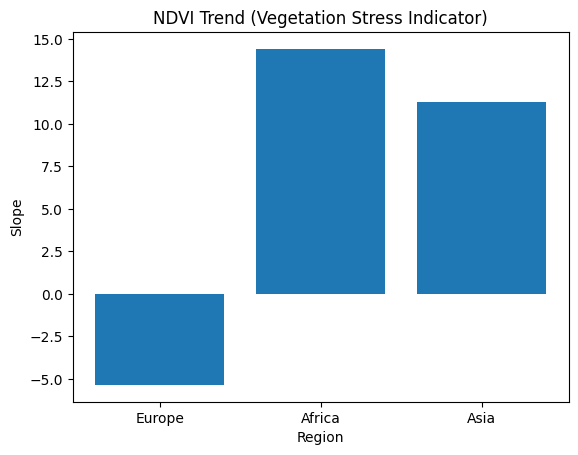


TEST:
STABLE 🌿


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [4]:
# ============================================
# 🌱 NDVI Vegetation Stress Analysis (NASA MODIS)
# CLEAN WORKING VERSION (Earth Engine + ML)
# ============================================

# =========================
# 1. INSTALL
# =========================
!pip install earthengine-api scikit-learn pandas numpy matplotlib --quiet

import ee
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# =========================
# 2. AUTH
# =========================
ee.Authenticate()

PROJECT_ID = "capable-matrix-325822"
ee.Initialize(project=PROJECT_ID)

print("✅ Earth Engine ready")

# =========================
# 3. MODIS NDVI DATA
# =========================
modis = ee.ImageCollection("MODIS/061/MOD13A2").select("NDVI")

start_year = 2015
end_year = 2023

# =========================
# 4. SIMPLE REGIONS (FIXED, NO ERRORS)
# =========================
# We use bounding boxes instead of broken datasets

europe = ee.Geometry.Rectangle([-10, 35, 30, 70])
africa = ee.Geometry.Rectangle([-20, -35, 55, 35])
asia   = ee.Geometry.Rectangle([30, 5, 150, 60])

regions = {
    "Europe": europe,
    "Africa": africa,
    "Asia": asia
}

# =========================
# 5. NDVI TREND FUNCTION
# =========================
def compute_trend(region_geom):

    values = []

    for year in range(start_year, end_year + 1):

        start = ee.Date.fromYMD(year, 1, 1)
        end = ee.Date.fromYMD(year, 12, 31)

        img = modis.filterDate(start, end).mean()

        val = img.reduceRegion(
            reducer=ee.Reducer.mean(),
            geometry=region_geom,
            scale=10000,
            maxPixels=1e13
        ).get("NDVI").getInfo()

        values.append(val)

    years = np.array(list(range(start_year, end_year + 1)))
    values = np.array(values)

    slope = np.polyfit(years, values, 1)[0]

    return np.mean(values), slope

# =========================
# 6. BUILD DATASET
# =========================
data = []

for name, geom in regions.items():

    mean_ndvi, slope = compute_trend(geom)

    label = 1 if slope < 0 else 0  # 1 = stress

    data.append([name, mean_ndvi, slope, label])

    print(f"{name} | NDVI={mean_ndvi:.4f} | slope={slope:.6f}")

df = pd.DataFrame(data, columns=["region", "mean_ndvi", "slope", "label"])

print("\nDATASET")
print(df)

# =========================
# 7. ML MODEL
# =========================
X = df[["mean_ndvi", "slope"]]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

pred = model.predict(X_test)

print("\nCLASSIFICATION REPORT")
print(classification_report(y_test, pred))

print("\nCONFUSION MATRIX")
print(confusion_matrix(y_test, pred))

# =========================
# 8. VISUALIZATION
# =========================
plt.figure()
plt.bar(df["region"], df["slope"])
plt.title("NDVI Trend (Vegetation Stress Indicator)")
plt.xlabel("Region")
plt.ylabel("Slope")
plt.show()

# =========================
# 9. PREDICT FUNCTION
# =========================
def predict(ndvi, slope):
    return "STRESSED 🌱" if model.predict([[ndvi, slope]])[0] == 1 else "STABLE 🌿"

print("\nTEST:")
print(predict(df["mean_ndvi"].mean(), df["slope"].mean()))